In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import catboost
import xgboost
#modelling
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
X = df.drop(columns=['math_score'],axis=1)

In [4]:
y = df['math_score']

In [5]:
#create column transformer with 3 types of transformer
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
    ("OneHotEncoder",oh_transformer,cat_features),
    ("StandardScalar",num_transformer,num_features)
])

X = preprocessor.fit_transform(X)

In [6]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=.20,random_state=42) 
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [17]:
def eval_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    r_square = r2_score(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    return mae,mse,r_square,rmse

In [18]:
models = {
"Linear Regression": LinearRegression(),
"Lasso": Lasso(),
"Ridge": Ridge(),
"K-Neighbors Regressor": KNeighborsRegressor(),
"Decision Tree": DecisionTreeRegressor(),
"Random Forest Regressor": RandomForestRegressor(),
"XGBRegressor": XGBRegressor(),
"CatBoosting Regressor": CatBoostRegressor(verbose=False),
"AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    #Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae ,model_train_mse, model_train_rmse, model_train_r2 = eval_model(y_train, y_train_pred)

    model_test_mae , model_test_mse, model_test_rmse, model_test_r2 = eval_model(y_test, y_test_pred)



    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for training set")
    print("Root Mean Squared Error:{: .4f}".format(model_train_rmse))
    print("Mean Squared Error:{: .4f}".format(model_train_mse))
    print("Mean Absolute Error:{: .4f}".format(model_train_mae))
    print("R2 Score:{: .4f}".format(model_train_r2))

    print('-'*20)

    print("Model Performance for testing set")
    print("Root Mean Squared Error:{: .4f}".format(model_test_rmse))
    print("Mean Squared Error:{: .4f}".format(model_test_rmse))
    print("Mean Absolute Error:{: .4f}".format(model_test_mae))
    print("R2 Score:{: .4f}".format(model_test_r2))

    r2_list.append(model_test_r2)
    print('='*30)
    print('\n')



Linear Regression
Model Performance for training set
Root Mean Squared Error: 0.8743
Mean Squared Error: 28.3349
Mean Absolute Error: 4.2667
R2 Score: 5.3231
--------------------
Model Performance for testing set
Root Mean Squared Error: 0.8804
Mean Squared Error: 0.8804
Mean Absolute Error: 4.2148
R2 Score: 5.3940


Lasso
Model Performance for training set
Root Mean Squared Error: 0.8071
Mean Squared Error: 43.4784
Mean Absolute Error: 5.2063
R2 Score: 6.5938
--------------------
Model Performance for testing set
Root Mean Squared Error: 0.8253
Mean Squared Error: 0.8253
Mean Absolute Error: 5.1579
R2 Score: 6.5197


Ridge
Model Performance for training set
Root Mean Squared Error: 0.8743
Mean Squared Error: 28.3378
Mean Absolute Error: 4.2650
R2 Score: 5.3233
--------------------
Model Performance for testing set
Root Mean Squared Error: 0.8806
Mean Squared Error: 0.8806
Mean Absolute Error: 4.2111
R2 Score: 5.3904


K-Neighbors Regressor
Model Performance for training set
Root Mean 

### Results

In [20]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name',"R2_Score"]).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
4,Decision Tree,8.101852
3,K-Neighbors Regressor,7.253041
1,Lasso,6.519695
6,XGBRegressor,6.473307
8,AdaBoost Regressor,6.017884
7,CatBoosting Regressor,6.008632
5,Random Forest Regressor,5.981220
0,Linear Regression,5.393994
2,Ridge,5.390387


### Linear Regression

In [21]:
lin_reg = LinearRegression(fit_intercept=True)
lin_reg = lin_reg.fit(X_train,y_train)
y_pred = lin_reg.predict((X_test))
score = r2_score(y_test,y_pred)*100
print("Accuracy of Model is %.2f"%score)

Accuracy of Model is 88.04


### Plot Y_pred and Y_test

Text(0, 0.5, 'Predicted')

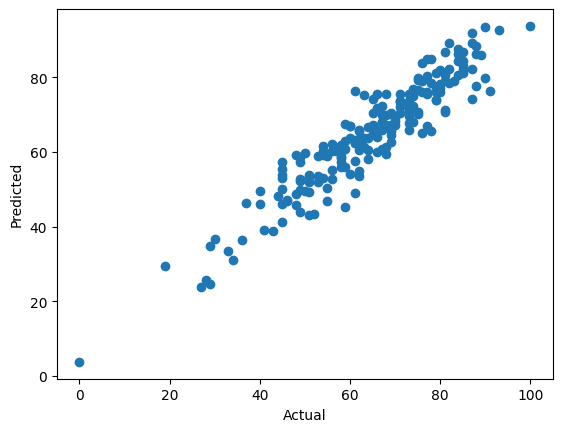

In [22]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

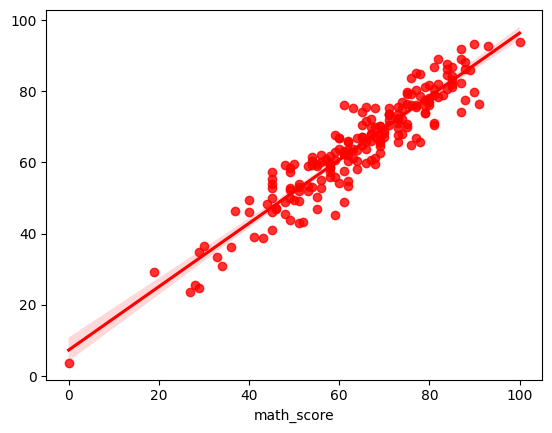

In [23]:
sns.regplot(x=y_test,y=y_pred,color='red')

#### Difference between actual and predicted value

In [24]:
pred_df = pd.DataFrame({"acutal value":y_test,"predicted value":y_pred,"Difference":y_test-y_pred})
pred_df

,acutal value,predicted value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
